In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

Loading the saved model

In [2]:
cat_model = joblib.load(
    "../models/catboost_log_model.pkl"
)

In [3]:
X_test = pd.read_csv(
    "../models/X_test_log.csv"
)

y_test = pd.read_csv(
    "../models/y_test_log.csv"
)

In [4]:
explainer = shap.TreeExplainer(cat_model)

shap_values = explainer.shap_values(X_test)

SHAP Summary Plot

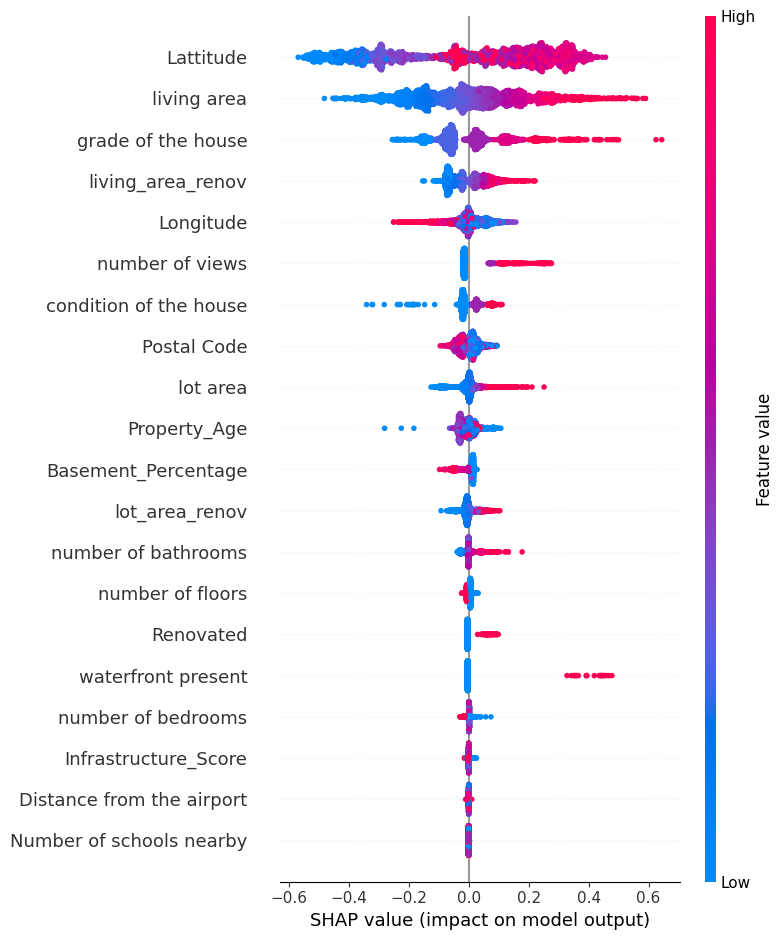

In [5]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Red = High Feature Values
Blue = Low Feature Values

Shap feature imp bar plot

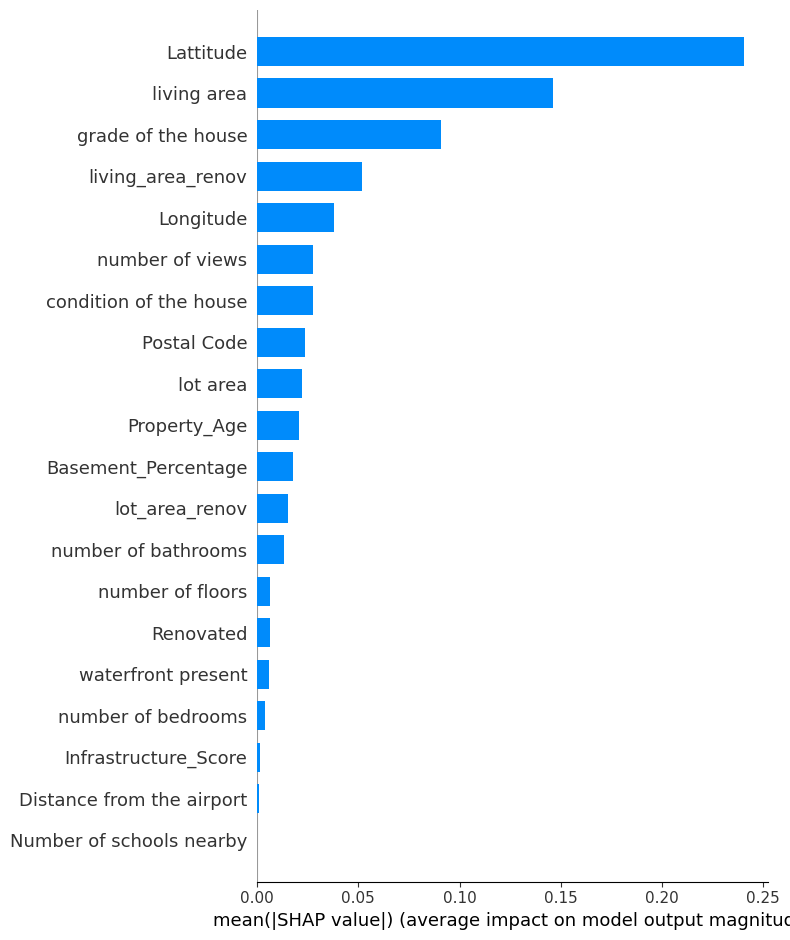

In [6]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/shap_bar_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Feature Importance Table

In [7]:
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values("Mean_SHAP", ascending=False)
    .reset_index(drop=True)
)

shap_importance.head(20)

,Feature,Mean_SHAP
0,Lattitude,0.240467
1,living area,0.146235
2,grade of the house,0.090880
3,living_area_renov,0.051965
4,Longitude,0.038083
5,number of views,0.027625
6,condition of the house,0.027418
7,Postal Code,0.023464
8,lot area,0.022256
9,Property_Age,0.020701


In [8]:
shap_importance.to_csv(
    "../reports/shap_feature_importance.csv",
    index=False
)

In [9]:
shap_importance.head(10)

,Feature,Mean_SHAP
0,Lattitude,0.240467
1,living area,0.146235
2,grade of the house,0.090880
3,living_area_renov,0.051965
4,Longitude,0.038083
5,number of views,0.027625
6,condition of the house,0.027418
7,Postal Code,0.023464
8,lot area,0.022256
9,Property_Age,0.020701


It means:

Location matters more than anything else.

The model learned:

Houses in premium locations command higher prices.

Larger houses command higher prices.

Higher construction quality increases value.

This is actually realistic for real estate.

SHAP waterfall plot

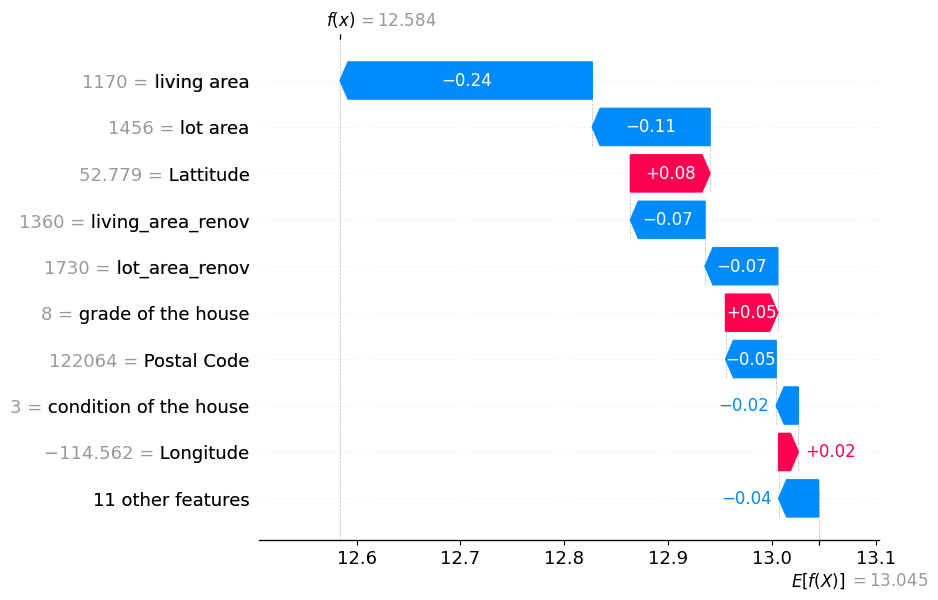

In [10]:
sample_idx = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_idx],
        feature_names=X_test.columns
    )
)